# Imports and Configuration

In [1]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

In [2]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [3]:
sn.set(font_scale=1.4)  # for label size

# Dataset Loading and Preprocessing

In [4]:
df = pd.read_csv("./JJM_Dataset.csv")
df = df.rename(
    columns={"L1 (OFF/L/M/H)": "L1", "L3 (OFF/L/M/H)": "L3", "L4 (OFF/L/M/H)": "L4"}
)
df = df.replace("OFF", 0).replace("L", 1).replace("M", 1).replace("H", 1)

## Feature Selection

Note: `fm2891` should be removed as its reading takes only two values and that too randomly. This can happen if the flow through the pipe actually does not change or the meter is malfunctioning. But this will make predicting leakages before and after the remaining two flow meters is going to be a challenge (even if we apply normal conservation laws of physics).

In [5]:
features_columns = ["fm3327", "fm3232", "fm2891"]
output_labels_columns = ["L1", "L3", "L4"]
train_test_column = "Train/Test"  # Manually generated Train/Test Split to avoid "memory" getting ingrained.

## Normalisation

As the inputs were too close to each other, they were normalised between 0 and 1.

In [6]:
min_max_scaler = preprocessing.MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(df[features_columns].values)
df[features_columns] = pd.DataFrame(x_scaled)

# Train/Test Split

To choose a method, uncomment and comment the appropriate block of code.

## Method 1: Manually created (experiment-wise) splits

The problem with this method is that test set may be way more biased than expected due to limited number of experiments.

In [7]:
# train_data = df[df[train_test_column] == "Train"]
# test_data = df[df[train_test_column] == "Test"]
# X_train = train_data[features_columns]
# y_train = train_data[output_labels_columns]

# X_test = test_data[features_columns]
# y_test = test_data[output_labels_columns]

## Method 2: Random Split

The problem with this method is that since the data is too repititive the model tends to memorize the outputs.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    df[features_columns], df[output_labels_columns], test_size=0.2, random_state=42
)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(540, 3) (540, 3) (136, 3) (136, 3)


# Models

One model is stored for each leakage and hence we get a multi-class classification problem.
It has been reduced to a binary classification as 4 other classes were combined into "ON" category.

## Decision Tree


Decision Tree Classifier for L1 Accuracy: 0.6397058823529411


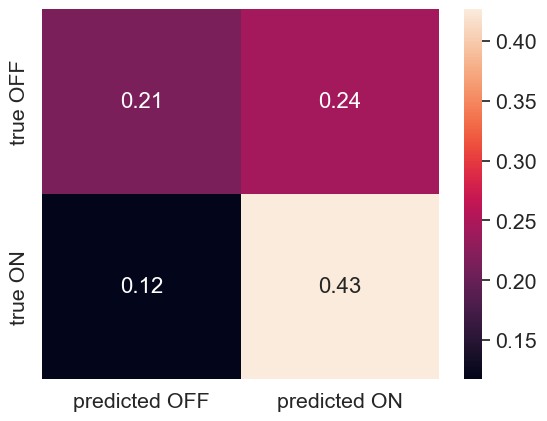


Decision Tree Classifier for L3 Accuracy: 0.5735294117647058


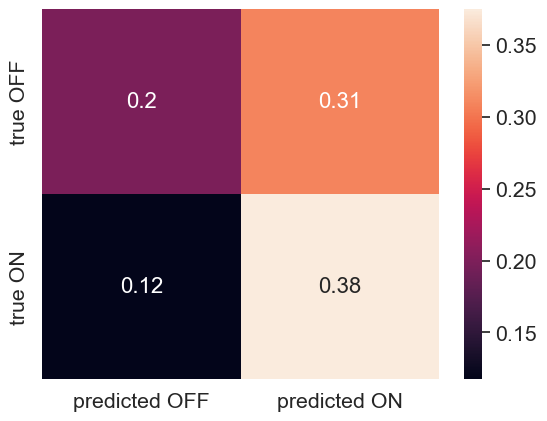


Decision Tree Classifier for L4 Accuracy: 0.5441176470588235


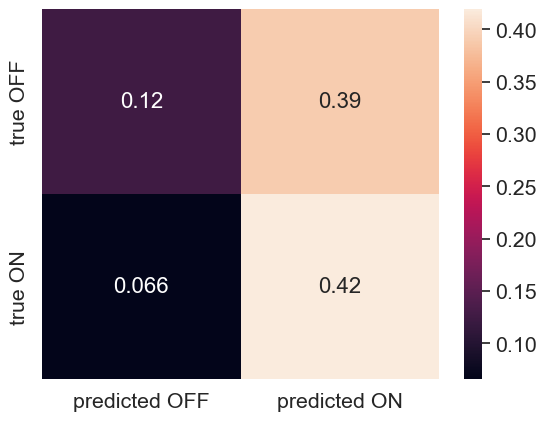

In [9]:
dtree_classifiers = {}

for col in output_labels_columns:
    dtree_classifier = DecisionTreeClassifier(random_state=42)
    dtree_classifier.fit(X_train, y_train[col])
    dtree_classifiers[col] = dtree_classifier
    dtree_predictions = dtree_classifier.predict(X_test)
    dtree_accuracy = accuracy_score(y_test[col], dtree_predictions)
    cm = confusion_matrix(y_test[col], dtree_predictions, normalize="all")
    print(f"\nDecision Tree Classifier for {col} Accuracy:", dtree_accuracy)
    sn.heatmap(
        pd.DataFrame(
            cm, index=["true OFF", "true ON"], columns=["predicted OFF", "predicted ON"]
        ),
        annot=True,
        annot_kws={"size": 16},
    )
    plt.show()

## Random Forest Classifier

It is performing similar to decision trees as the amount of unique data is too small and repitive so random sampling does not help.


Logistic Regression Classifier for L1 Accuracy: 0.6544117647058824


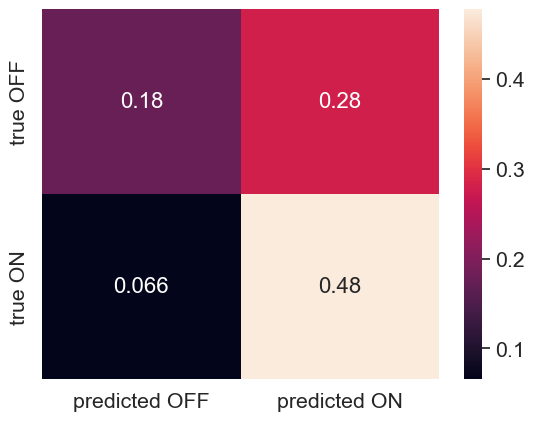


Logistic Regression Classifier for L3 Accuracy: 0.5735294117647058


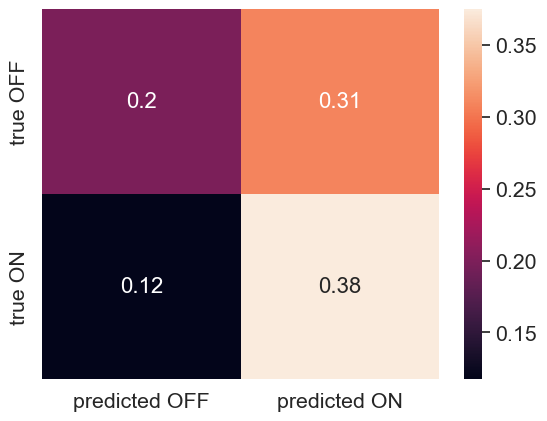


Logistic Regression Classifier for L4 Accuracy: 0.5441176470588235


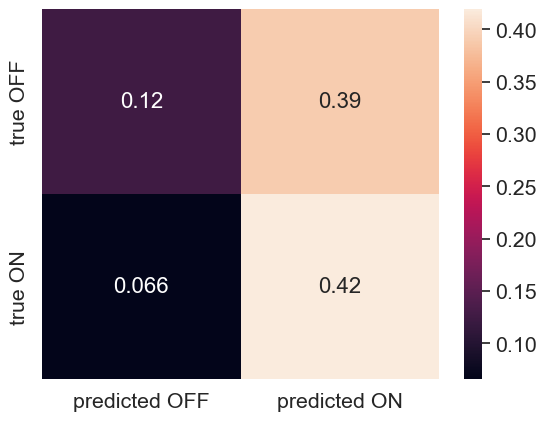

In [11]:
rf_classifiers = {}

for col in output_labels_columns:
    rf_classifier = RandomForestClassifier(max_depth=4, random_state=42)
    rf_classifier.fit(X_train, y_train[col])
    rf_classifiers[col] = rf_classifier
    rf_predictions = rf_classifier.predict(X_test)
    rf_accuracy = accuracy_score(y_test[col], rf_predictions)
    cm = confusion_matrix(y_test[col], rf_predictions, normalize="all")
    print(f"\nLogistic Regression Classifier for {col} Accuracy:", rf_accuracy)
    sn.heatmap(
        pd.DataFrame(
            cm, index=["true OFF", "true ON"], columns=["predicted OFF", "predicted ON"]
        ),
        annot=True,
        annot_kws={"size": 16},
    )
    plt.show()

## Logistic Regression

It is easily learning bias due to the repitions in the data.


Logistic Regression Classifier for L1 Accuracy: 0.5735294117647058


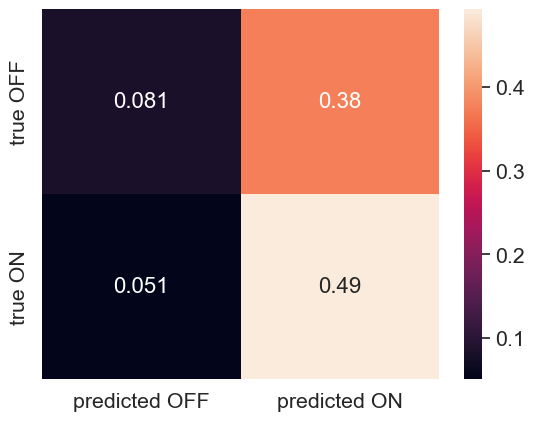


Logistic Regression Classifier for L3 Accuracy: 0.5220588235294118


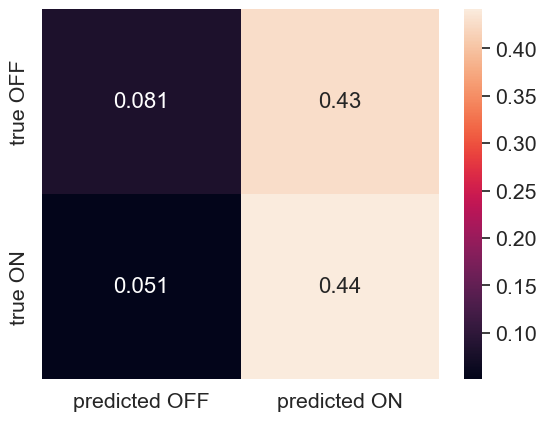


Logistic Regression Classifier for L4 Accuracy: 0.5808823529411765


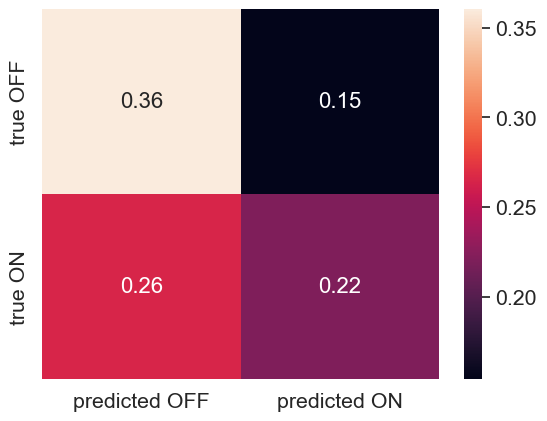

In [12]:
logreg_classifiers = {}

for col in output_labels_columns:
    logreg_classifier = LogisticRegression(random_state=42)
    logreg_classifier.fit(X_train, y_train[col])
    logreg_classifiers[col] = logreg_classifier
    logreg_predictions = logreg_classifier.predict(X_test)
    logreg_accuracy = accuracy_score(y_test[col], logreg_predictions)
    cm = confusion_matrix(y_test[col], logreg_predictions, normalize="all")
    print(f"\nLogistic Regression Classifier for {col} Accuracy:", logreg_accuracy)
    sn.heatmap(
        pd.DataFrame(
            cm, index=["true OFF", "true ON"], columns=["predicted OFF", "predicted ON"]
        ),
        annot=True,
        annot_kws={"size": 16},
    )
    plt.show()